In [5]:
from sr_model import single_sr, paired_sr, phase_1_train, phase_2_train
import numpy as np
import muon as mu 
import scanpy as sc
from dataset import single_data
import yaml 
import torch

### load data

In [2]:
def load_data(eval_id):
    mdata = mu.read_h5mu('/home/rsun@ZHANGroup.local/multi_pretrain/evaluation/notebook/eval_data/M_rna_1/mdata.h5mu')
    
    rna = mdata['rna_count']
    gadata = mdata['ga_count'] 

    mutual_gene = np.load('/home/rsun@ZHANGroup.local/atac_pretrain/src/mutual_gene.npy', allow_pickle=True)
    gadata = gadata[:,mutual_gene]
    
    # lo1p transform 

    sc.pp.normalize_total(gadata, target_sum= 1e4)
    sc.pp.log1p(gadata)

    sc.pp.normalize_total(rna, target_sum= 1e4)
    sc.pp.log1p(rna)
    
    print(rna.shape, gadata.shape)

    path_1 = f'/home/rsun@ZHANGroup.local/multi_pretrain/evaluation/sr_result/train_test_split/eval_{eval_id}_train_id.npy'
    path_2 = f'/home/rsun@ZHANGroup.local/multi_pretrain/evaluation/sr_result/train_test_split/eval_{eval_id}_test_id.npy' 

    train_idx = np.load(path_1, allow_pickle=True)
    test_idx = np.load(path_2, allow_pickle=True) 

    rna_train, rna_test = rna[train_idx,:], rna[test_idx,:]
    gadata_train, gadata_test = gadata[train_idx,:], gadata[test_idx,:]
    return rna_train, rna_test, gadata_train, gadata_test

In [3]:
rna_train, rna_test, gadata_train, gadata_test = load_data(eval_id = 1)
print(rna_test.shape, gadata_test.shape,rna_train.shape, gadata_train.shape)

/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/mudata/_core/mudata.py:931: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. U

(71002, 32285) (71002, 31899)
(1418, 32285) (1418, 31899) (12760, 32285) (12760, 31899)


In [8]:
rna_train = rna_train.X.toarray().astype(np.float32)
rna_test = rna_test.X.toarray().astype(np.float32)

rna_train = torch.from_numpy(rna_train)
rna_test = torch.from_numpy(rna_test)

rna = torch.vstack([rna_train, rna_test])
print(rna.shape)

torch.Size([14178, 32285])


In [9]:
from torch.utils.data import Dataset, DataLoader 
rna_dataset = single_data(rna)
rna_loader = DataLoader(rna_dataset, batch_size=1024, shuffle=True)

In [15]:
gadata_train = gadata_train.X.toarray().astype(np.float32)
gadata_test = gadata_test.X.toarray().astype(np.float32)

gadata_train = torch.from_numpy(gadata_train)
gadata_test = torch.from_numpy(gadata_test)

In [16]:
from dataset import omic_data

train_dataset = omic_data(rna_train, gadata_train)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

test_dataset = omic_data(rna_test, gadata_test)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=True)

### load model

In [10]:


with open('/home/rsun@ZHANGroup.local/sr_project/saved_models/config_small_2025-02-27-05-24/config.yaml','r') as f:
    config = yaml.safe_load(f)

print(config)

checkpoint_path ='/home/rsun@ZHANGroup.local/sr_project/saved_models/config_small_2025-02-27-05-24/checkpoint_16000.pth'
sr_rna = single_sr(config)
checkpoint = torch.load(checkpoint_path)
sr_rna.model.load_state_dict(checkpoint['model_state_dict'])

rna_model = sr_rna.model



{'network': {'activation': 'leaky_relu', 'ce_weights': {'class': 15, 'neurotransmitter': 20, 'subclass': 5, 'supertype': 2.5}, 'class_dict': {'class': 34, 'neurotransmitter': 10, 'subclass': 338, 'supertype': 1201}, 'dropout': 0.1, 'feature_num': 32285, 'hidden_dims': [512, 256, 128], 'input_dropout': 0.4, 'layernorm_eps': 1e-08, 'vae_weight': 0}, 'omic': {'model_type': 'rna'}, 'optimizer': {'anneal_steps': 12000, 'learning_rate': 0.0001, 'min_lr': 1e-07, 'warmup_steps': 2000, 'weight_decay': 0.1}, 'training': {'device': 'cuda', 'eval_steps': 100, 'log_dir': 'logs', 'run_name': 'config_small', 'save_dir': 'saved_models', 'save_steps': 4000, 'training_steps': 16000}}


/tmp/ipykernel_31030/3004128278.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


In [11]:
rna_model = phase_1_train(rna_model,
                rna_loader,
                'logs/test_rna',
                'saved_models/test_rna',
                training_steps = 1000,
                lr = 1e-5,
                device = 'cuda')

Final checkpoint saved at saved_models/test_rna/phase_1_2025-02-27-11-19/checkpoint_1000.pth


In [12]:
with open('/home/rsun@ZHANGroup.local/sr_project/saved_models/ga_config_small_2025-02-27-05-24/config.yaml','r') as f:
    config = yaml.safe_load(f)

print(config)

checkpoint_path ='/home/rsun@ZHANGroup.local/sr_project/saved_models/ga_config_small_2025-02-27-05-24/checkpoint_12000.pth'
sr_ga = single_sr(config)
checkpoint = torch.load(checkpoint_path)
sr_ga.model.load_state_dict(checkpoint['model_state_dict'])

ga_model = sr_ga.model

{'network': {'activation': 'leaky_relu', 'ce_weights': {'L1': 15, 'L3': 2.5, 'NeuronTransmitter': 20, 'Subclass': 5}, 'class_dict': {'L1': 37, 'L3': 899, 'NeuronTransmitter': 8, 'Subclass': 275}, 'dropout': 0.1, 'feature_num': 31899, 'hidden_dims': [512, 256, 128], 'input_dropout': 0.4, 'layernorm_eps': 1e-08, 'vae_weight': 0}, 'omic': {'model_type': 'ga'}, 'optimizer': {'anneal_steps': 10000, 'learning_rate': 0.0001, 'min_lr': 1e-07, 'warmup_steps': 1200, 'weight_decay': 0.1}, 'training': {'device': 'cuda', 'eval_steps': 100, 'log_dir': 'logs', 'run_name': 'ga_config_small', 'save_dir': 'saved_models', 'save_steps': 6000, 'training_steps': 12000}}


/tmp/ipykernel_31030/458751290.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


In [14]:
from sr_net import multi_model

paired_model = multi_model(rna_model, ga_model)
paired_model.freeze_param()

... storing 'batch' as categorical
... storing 'batch' as categorical
... storing 'batch' as categorical
/home/rsun@ZHANGroup.local/sr_project/src/custom_scheduler.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(self.min_lr + (base_lr - self.min_lr) * (0.5 * (1.0 + torch.cos(torch.pi * progress)))).to(torch.float32)
... storing 'batch' as categorical
/home/rsun@ZHANGroup.local/sr_project/src/custom_scheduler.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(self.min_lr + (base_lr - self.min_lr) * (0.5 * (1.0 + torch.cos(torch.pi * progress)))).to(torch.float32)
... storing 'batch' as categorical
/home/rsun@ZHANGroup.local/sr_project/src/cus

training finished, perform evaluation


100%|██████████| 19/19 [00:28<00:00,  1.52s/it]


program over


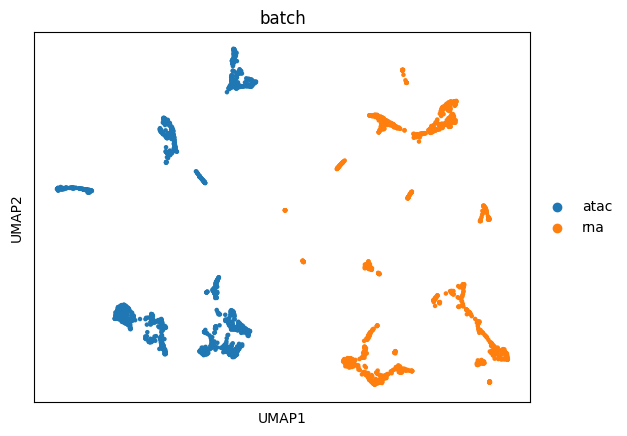

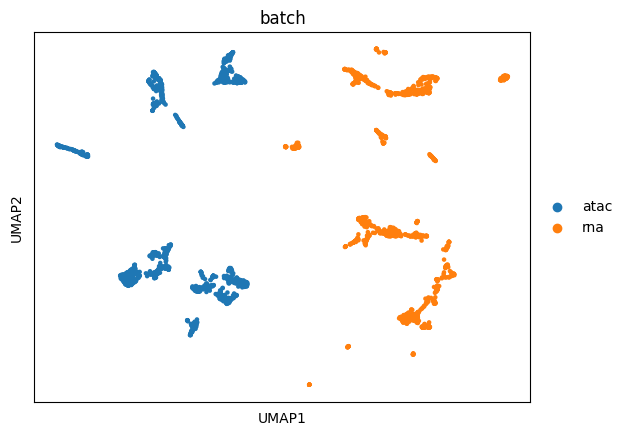

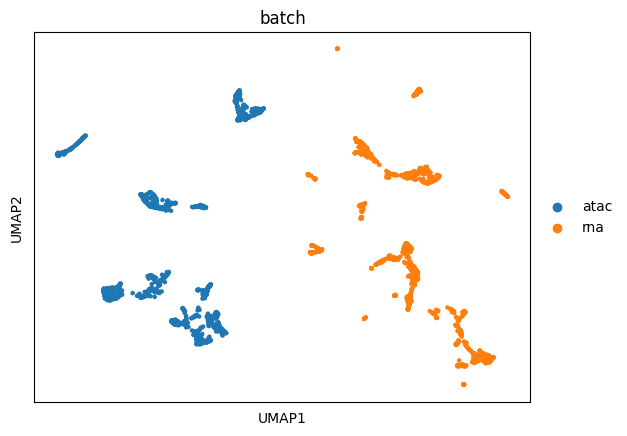

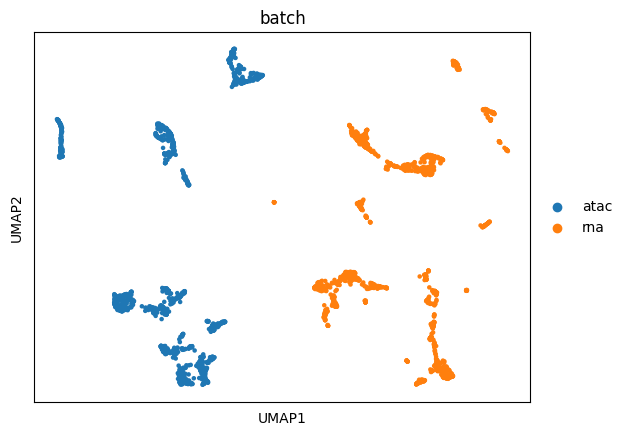

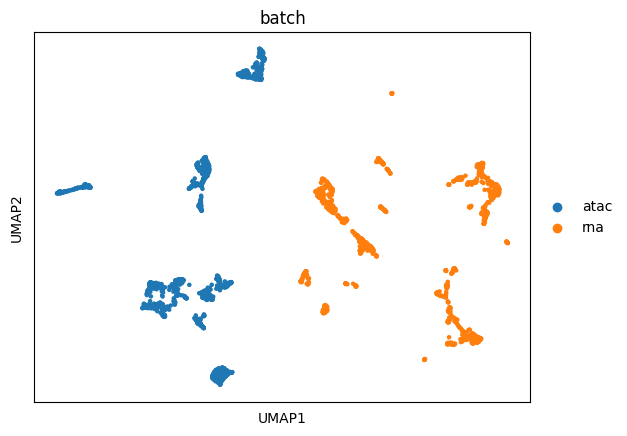

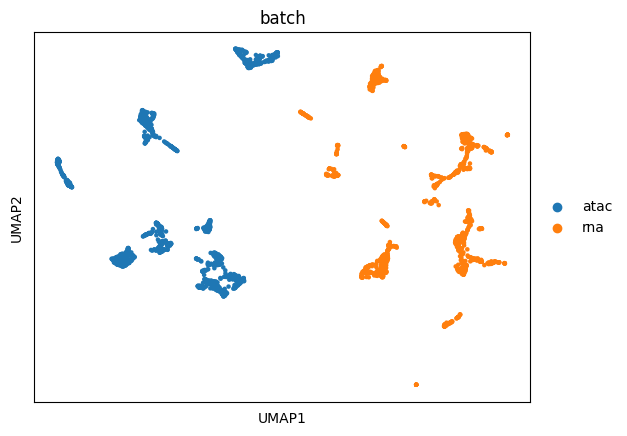

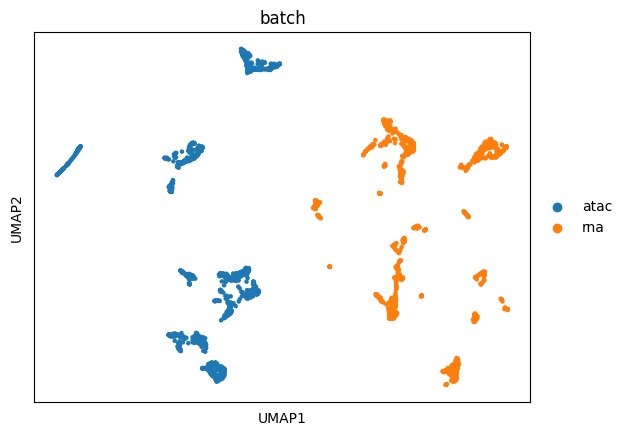

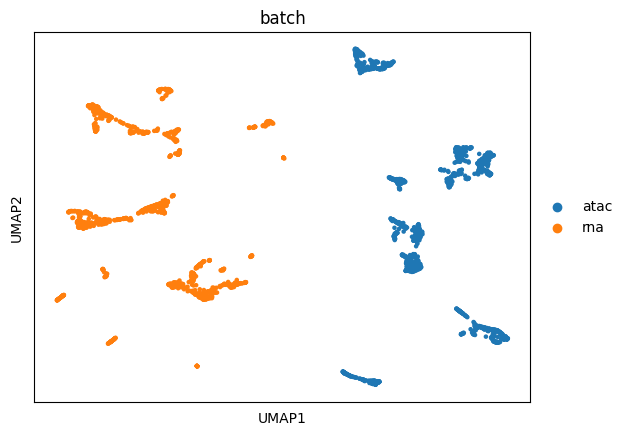

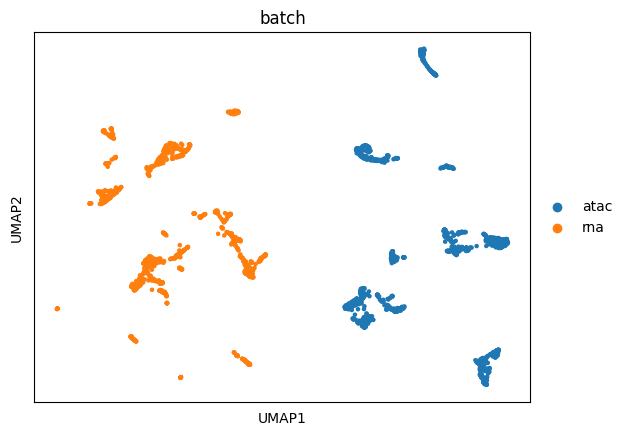

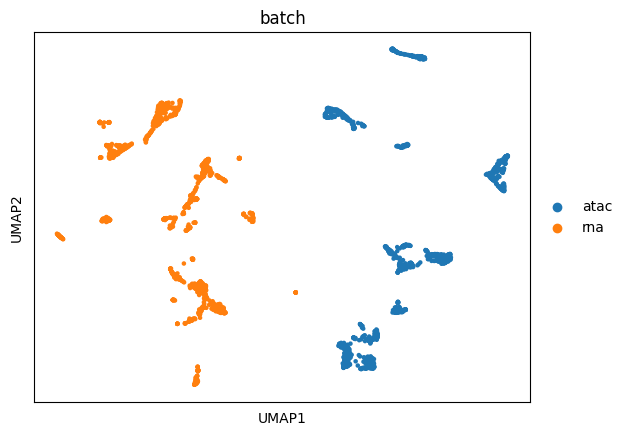

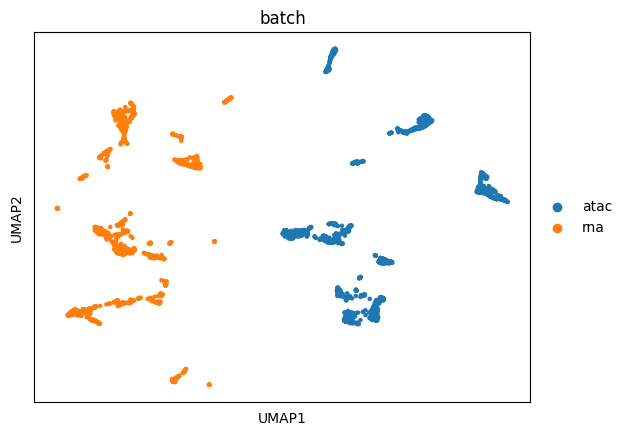

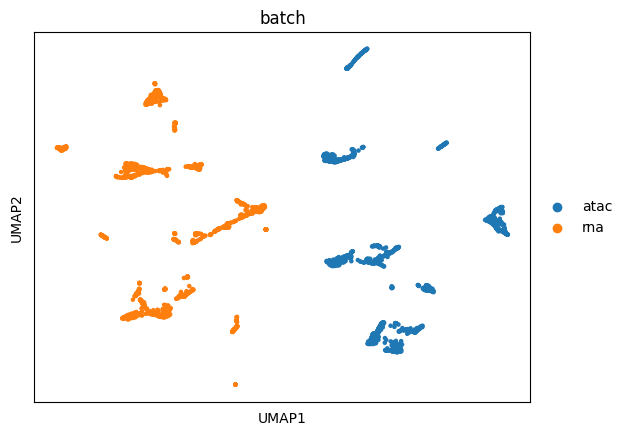

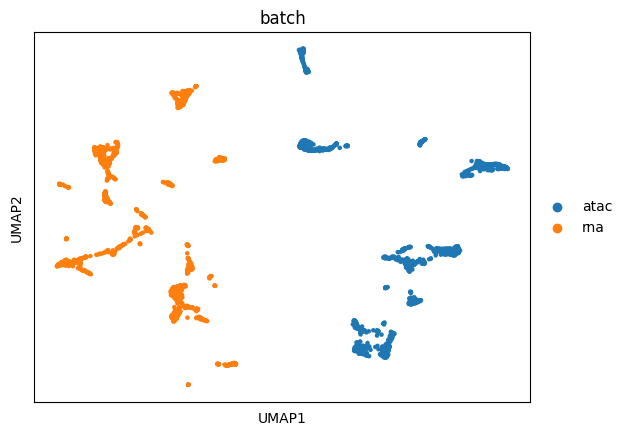

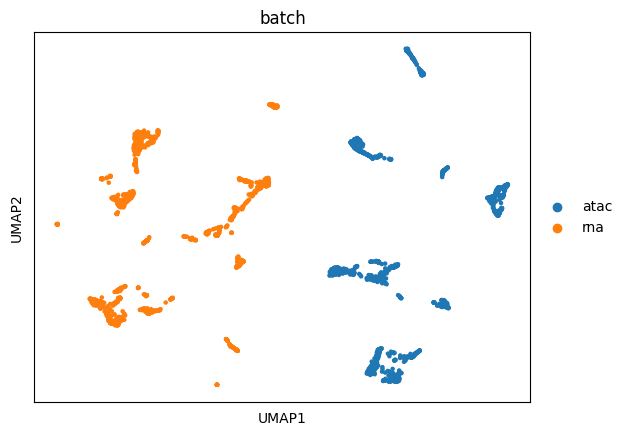

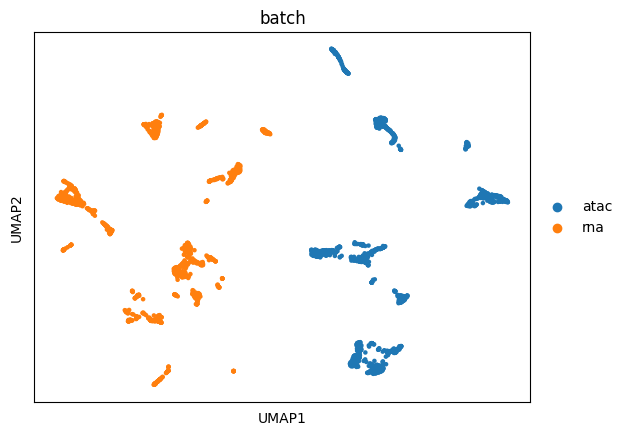

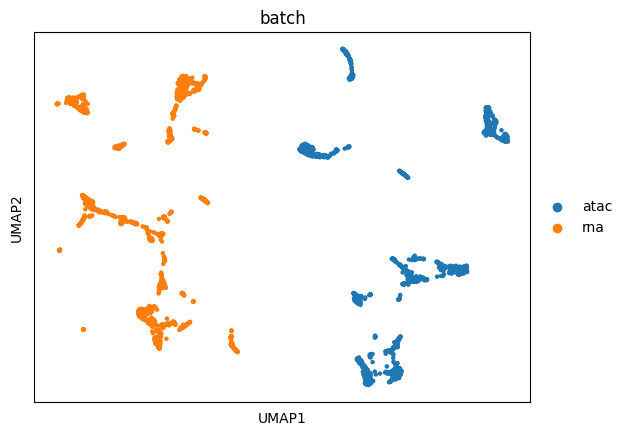

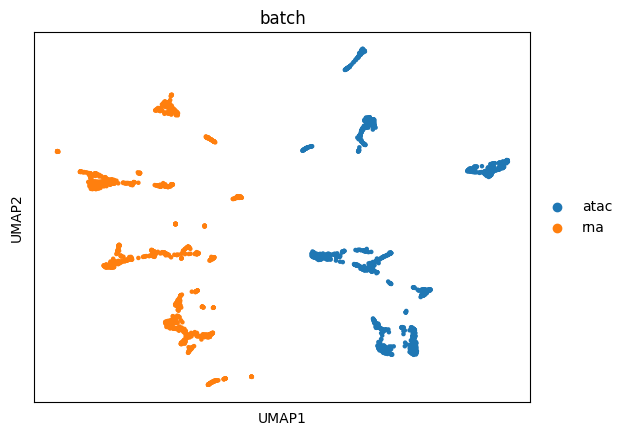

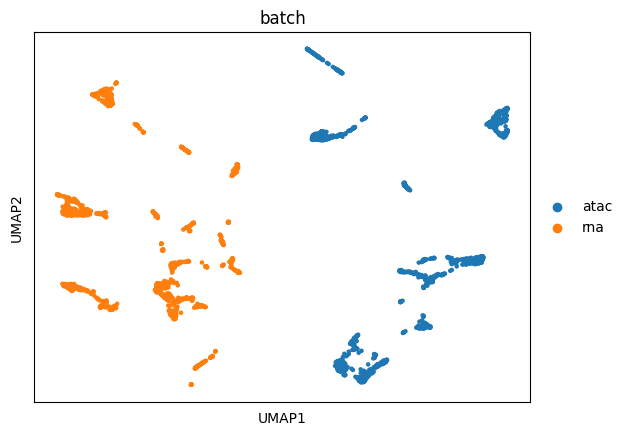

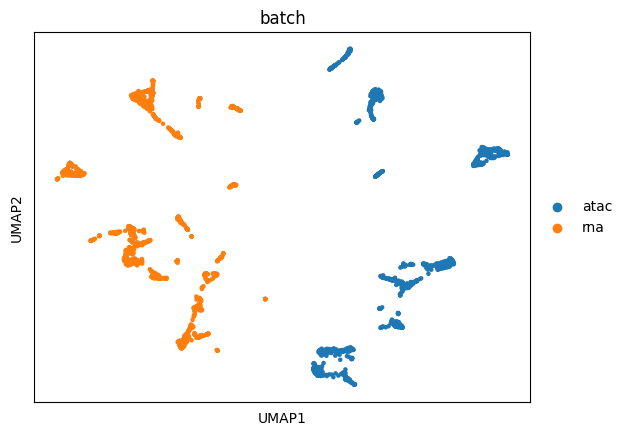

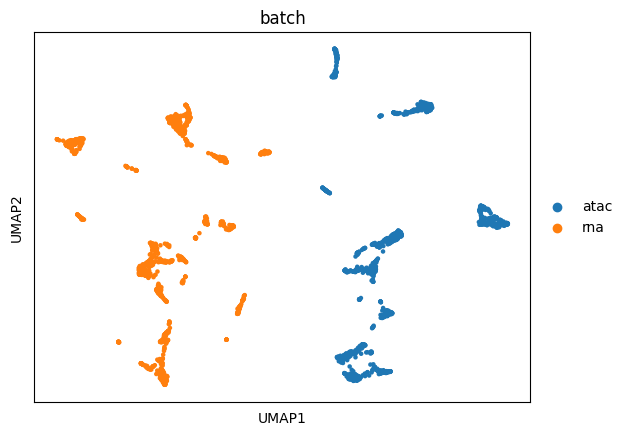

In [22]:
paired_model = phase_2_train(model = paired_model,
                             train_loader= train_loader,
                             test_loader= test_loader,
                             log_dir = 'logs/test_pair',
                             save_dir = 'saved_models/test_pair',
                             training_steps= 1000,
                             eval_steps= 50,
                             save_steps= 500,
                             lr = 1e-5,
                             min_lr = 5e-6,
                             warmup_steps= 200,
                             anneal_steps= 800,
                             device = 'cuda')

In [21]:
"""
Define the solid recover model
"""
import torch 
import torch.nn as nn 
import torch.nn.functional as F
import numpy as np 
from sr_net import sr_single_omic, multi_model
import custom_scheduler
import os
from datetime import datetime
from torch.utils.tensorboard import SummaryWriter
from dataclasses import dataclass, field
from typing import Dict, List, Optional
import torch.optim as optim
import yaml
import muon as mu 
from torch.utils.data import DataLoader  
from dataset import omic_data 
import scanpy as sc
import anndata as ad
from tqdm import tqdm 
import sys 
sys.path.append('/home/rsun@ZHANGroup.local/multi_pretrain/evaluation')
from eval_scores import calculate_hit_rate, matching_metrics
import pandas as pd

def phase_2_train(model,
                  train_loader,
                  test_loader,
                  log_dir,
                  save_dir,
                  training_steps, 
                  eval_steps,
                  save_steps,
                  lr,
                  min_lr,
                  warmup_steps,
                  anneal_steps,
                  device = 'cuda',
):
    
    ### create log_dir and save_dir

    timestamp = datetime.now().strftime('%Y-%m-%d_%H_%M')
    log_dir = os.path.join(log_dir, f'phase_2_{timestamp}')
    save_dir = os.path.join(save_dir, f'phase_2_{timestamp}')

    os.makedirs(save_dir, exist_ok= True)
    os.makedirs(log_dir, exist_ok= True)

    ### make logger, optimizer, scheduler
    writer = SummaryWriter(log_dir)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, 
                                model.parameters()), lr=lr)
    model.to(device)

    scheduler = custom_scheduler.WarmupCosineScheduler(
                optimizer=optimizer,
                warmup_steps=warmup_steps,
                anneal_steps=anneal_steps,
                min_lr=min_lr)
    
    ### calculate num_epochs 

    num_epochs = training_steps // len(train_loader) + 1
    steps = 0 

    ### training loop 
    for epoch in range(num_epochs):

        for batch in train_loader:
            model.train()

            rna = batch['rna'].to(device)
            ga = batch['ga'].to(device)

            outputs = model(rna, ga) 
            loss = outputs['loss'] 

            loss.backward() 
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            steps += 1 

            """
            Update writer
            """
            for key, values in outputs.items():
                if 'loss' in key:
                    writer.add_scalar(f'{key}/train', values, steps)
            writer.add_scalar('lr', scheduler.get_last_lr()[0], steps)

        
            '''save model when reach save steps'''

            if steps % save_steps == 0:
                checkpoint_path = os.path.join(save_dir, f'checkpoint_{steps}.pth')
                torch.save({'model_state_dict': model.state_dict()},checkpoint_path)

            '''perform evaluation when reach eval steps'''

            if steps % eval_steps == 0:
                model.eval()

                eval_dic = {}
                eval_count = 0

                rna_embed_list = []
                ga_embed_list = []

                with torch.no_grad():
                    for batch in test_loader:
                        rna = batch['rna'].to(device)
                        ga = batch['ga'].to(device)
                        outputs = model(rna, ga)

                        N = rna.shape[0]
                        eval_count += N

                        rna_embed_list.append(outputs['rna_embed'].detach().cpu().numpy())
                        ga_embed_list.append(outputs['ga_embed'].detach().cpu().numpy())

                        for key, value in outputs.items():
                            if 'loss' in key:
                                if key not in eval_dic:
                                    eval_dic[key] = value*N
                                else:
                                    eval_dic[key] += value*N
                        
                    for key in eval_dic:
                        writer.add_scalar(f'{key}/val', eval_dic[key]/eval_count, steps)


                '''save the embedding'''   
                rna_embed = np.concatenate(rna_embed_list)
                ga_embed = np.concatenate(ga_embed_list) 
                
                N = rna_embed.shape[0]
                sc_test = ad.AnnData(X = np.random.randn(N*2, 10),)

                sc_test.obs.loc[:,'batch'] = ['rna']*N + ['atac']*N
                sc_test.obs.loc[:,'idx'] = np.concatenate([np.arange(N), np.arange(N)])
                sc_test.obsm['X_embed'] = np.concatenate([rna_embed, ga_embed])

                sc.pp.neighbors(sc_test, use_rep = 'X_embed',metric='cosine')
                sc.tl.umap(sc_test, min_dist = 0.1)

                ax = sc.pl.umap(sc_test, color = 'batch', show=False)
                fig = ax.get_figure()

                ##### save model_weights, figure, model_embedding
                fig.savefig(os.path.join(save_dir, f'{steps}_umap_vis.png'),bbox_inches='tight')
                sc_test.write_h5ad(os.path.join(save_dir, f'model_embed_{steps}.h5ad'))

            if steps >= training_steps:
                break
    '''
    save the final model
    '''
    checkpoint_path = os.path.join(save_dir, f'checkpoint_{steps}.pth')
    torch.save({'model_state_dict': model.state_dict()},checkpoint_path)

    print('training finished, perform evaluation')
    ## After training, generate the evaluation score
    result = []
    idx = []

    for key in tqdm(range(eval_steps, training_steps, eval_steps)):
        idx.append(f'epoch_{key}')
        #print(str(key) + '===='*15)
        path = os.path.join(save_dir, f'model_embed_{key}.h5ad')
        sc_test = ad.read_h5ad(path)
        rna = sc_test.obsm['X_embed'][sc_test.obs.batch == 'rna']
        atac = sc_test.obsm['X_embed'][sc_test.obs.batch == 'atac']

        ### calculate top_k hit rate
        tmp = []
        for i in [2,5,10,15,20,30,50,100]:
            tmp.append(calculate_hit_rate(rna, atac, i, metric = 'cosine'))

        ### calculate metric score
        acc, ms, fs = matching_metrics(x=rna, y=atac, metric='cosine')
        tmp = tmp + [acc,ms,fs]
        result.append(tmp)

    columns = [f'top_{i}_hit' for i in [2,5,10,15,20,30,50,100]]
    columns = columns + ['acc', 'matchscore', 'foscttm']
    res_df =pd.DataFrame(result, index = idx, columns = columns)
    res_df.to_csv(os.path.join(save_dir, 'eval_result.csv'))
    print('program over')
    return None 
